# Baseline CNN on CIFAR-100 — Curated Experiment Suite

[![Open 02 in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fgram-devAI/deepl-cifar100-image-analysis/blob/main/notebooks/02_baseline_cnn_training.ipynb)

Standalone Colab-friendly notebook. Trains the baseline CNN on six curated
CIFAR-100 tasks and prints a compact comparison table.

**Experiments (in order):**
1. `food_containers` — coarse binary, strong object baseline
2. `aquatic_mammals` — coarse binary, harder animal baseline
3. `skyscraper` — fine binary, strongest single-class result
4. `orange` — fine binary, plain baseline
5. `orange_aug_light` — fine binary, light-augmentation ablation vs. orange
6. `coarse_multiclass` — 20-way coarse classification, motivates transfer learning

**Convention:** Does NOT import from local `data/`, `models/`, `training/`, or
`evaluation/`. Everything is inlined for Colab portability.

## 1. Setup

Install missing dependencies via `subprocess` (avoiding `%pip` magic so static type checkers do not flag the notebook). Then import, seed NumPy / TensorFlow / Python `random`, and define the global config dict that drives the run.


In [1]:
# Install dependencies on demand for a fresh Colab environment. We gate every install
# on a successful import to avoid re-resolving an already-working package set, which
# in particular protects the typing_extensions version that the local kernel needs.
import subprocess
import sys


def _ensure(module_name: str, pip_name: str | None = None) -> None:
    try:
        __import__(module_name)
    except ImportError:
        target = pip_name or module_name
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", target]
        )


_ensure("datasets")
_ensure("sklearn", "scikit-learn")
_ensure("yaml", "pyyaml")
_ensure("matplotlib")


In [2]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")  # suppress Metal INFO logs

import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import yaml
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("tensorflow:", tf.__version__)
print("numpy:     ", np.__version__)

tensorflow: 2.20.0
numpy:      2.0.2


In [3]:
# Flip to False for full CIFAR-100 runs with curated epoch counts.
FAST_DEV_RUN = False

DEFAULT_EPOCHS = {
    "food_containers":   20,
    "aquatic_mammals":   30,
    "skyscraper":        80,
    "orange":            40,
    "orange_aug_light":  40,
    "coarse_multiclass": 30,
}

FAST_EPOCHS = {k: 2 for k in DEFAULT_EPOCHS}
FAST_SUBSET = 1024

OUTPUT_DIR = Path("tmp/baseline_cnn_notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("FAST_DEV_RUN:", FAST_DEV_RUN)
print("output dir:", OUTPUT_DIR.resolve())

FAST_DEV_RUN: False
output dir: /content/tmp/baseline_cnn_notebook


## 2. Load CIFAR-100 from Hugging Face

We pull both splits and convert the PIL images into `(N, 32, 32, 3) uint8` NumPy arrays. The first load downloads ~170 MB and caches under `~/.cache/huggingface/`.


In [4]:
ds = load_dataset("uoft-cs/cifar100")
train_split = ds["train"]
test_split = ds["test"]

fine_names = train_split.features["fine_label"].names
coarse_names = train_split.features["coarse_label"].names


def split_to_arrays(split):
    """Convert a HF split into (images uint8, fine int64, coarse int64) arrays."""
    images = np.stack(
        [np.asarray(row["img"].convert("RGB"), dtype=np.uint8) for row in split]
    )
    fine = np.asarray(split["fine_label"], dtype=np.int64)
    coarse = np.asarray(split["coarse_label"], dtype=np.int64)
    return images, fine, coarse


train_images, train_fine, train_coarse = split_to_arrays(train_split)
test_images, test_fine, test_coarse = split_to_arrays(test_split)

print("train images:", train_images.shape, train_images.dtype)
print("test  images:", test_images.shape, test_images.dtype)
print("coarse range:", int(train_coarse.min()), int(train_coarse.max()))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

train images: (50000, 32, 32, 3) uint8
test  images: (10000, 32, 32, 3) uint8
coarse range: 0 19


In [5]:
# Label-map helpers — keep these explicit so every experiment references
# names, not magic integers.
FINE_ID   = {name: i for i, name in enumerate(fine_names)}
COARSE_ID = {name: i for i, name in enumerate(coarse_names)}

print("fine classes (first 10):",  list(FINE_ID.items())[:10])
print("coarse classes:", list(COARSE_ID.items()))

fine classes (first 10): [('apple', 0), ('aquarium_fish', 1), ('baby', 2), ('bear', 3), ('beaver', 4), ('bed', 5), ('bee', 6), ('beetle', 7), ('bicycle', 8), ('bottle', 9)]
coarse classes: [('aquatic_mammals', 0), ('fish', 1), ('flowers', 2), ('food_containers', 3), ('fruit_and_vegetables', 4), ('household_electrical_devices', 5), ('household_furniture', 6), ('insects', 7), ('large_carnivores', 8), ('large_man-made_outdoor_things', 9), ('large_natural_outdoor_scenes', 10), ('large_omnivores_and_herbivores', 11), ('medium_mammals', 12), ('non-insect_invertebrates', 13), ('people', 14), ('reptiles', 15), ('small_mammals', 16), ('trees', 17), ('vehicles_1', 18), ('vehicles_2', 19)]


## 2b. Dataset Visualization

Sample grids of CIFAR-100 binary tasks and a class-balance bar chart make the
positive/negative imbalance visually concrete. These helpers are reused later
to inspect any task before training.


In [6]:
def plot_task_samples(images, binary_labels, *, positive_label=1, title="", n=12):
    """Show n CIFAR-100 images for a binary task in a 3x4 grid.

    Half are positives (binary_labels == positive_label), half are negatives.
    """
    images = np.asarray(images)
    binary_labels = np.asarray(binary_labels).reshape(-1)
    pos_idx = np.flatnonzero(binary_labels == positive_label)
    neg_idx = np.flatnonzero(binary_labels != positive_label)

    n_pos = min(n // 2, pos_idx.size)
    n_neg = min(n - n_pos, neg_idx.size)
    rng = np.random.default_rng(SEED)
    pick_pos = rng.choice(pos_idx, size=n_pos, replace=False) if n_pos else np.array([], dtype=int)
    pick_neg = rng.choice(neg_idx, size=n_neg, replace=False) if n_neg else np.array([], dtype=int)

    cols = 4
    rows = int(np.ceil((n_pos + n_neg) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))
    axes = np.atleast_2d(axes).reshape(-1)
    selected = list(pick_pos) + list(pick_neg)
    captions = ["pos"] * n_pos + ["neg"] * n_neg
    for ax, idx, cap in zip(axes, selected, captions):
        img = images[idx]
        if img.dtype != np.uint8:
            img = np.clip(img, 0.0, 1.0)
        ax.imshow(img)
        ax.set_title(cap, fontsize=8)
        ax.axis("off")
    for ax in axes[len(selected):]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


def plot_class_balance(labels, title=""):
    """Bar chart of label counts. Works for binary or small multiclass."""
    labels = np.asarray(labels).reshape(-1)
    values, counts = np.unique(labels, return_counts=True)
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.bar([str(v) for v in values], counts, color=["#4c72b0", "#dd8452"][: len(values)])
    for v, c in zip(values, counts):
        ax.text(str(v), c, f"{c}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("count")
    ax.set_xlabel("label")
    if title:
        ax.set_title(title, fontsize=11)
    fig.tight_layout()
    plt.show()


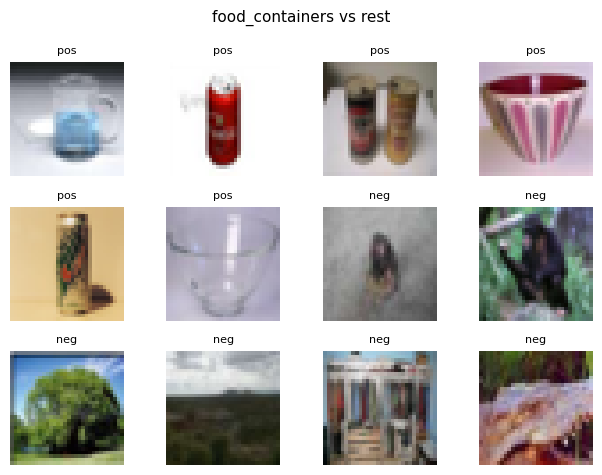

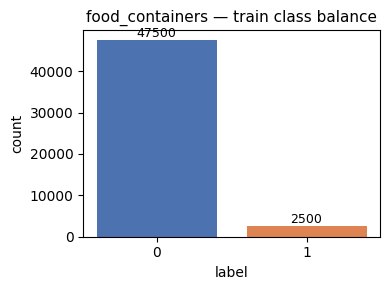

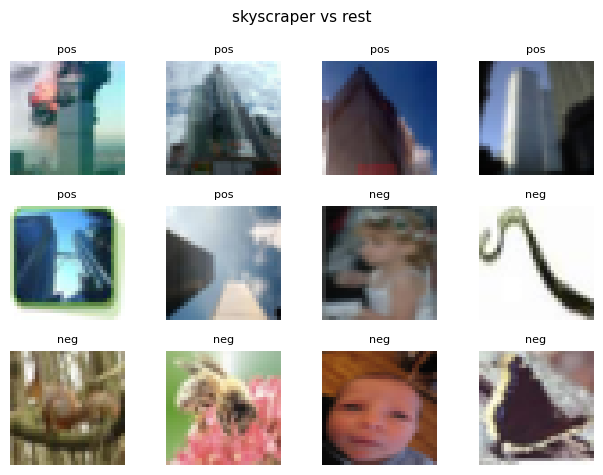

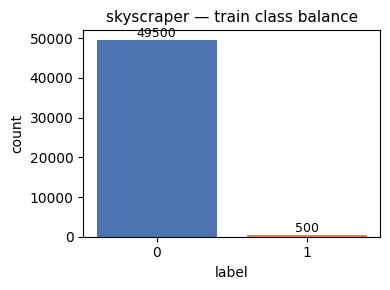

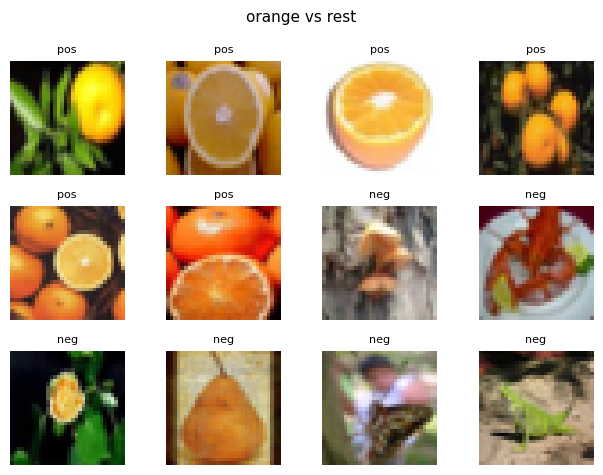

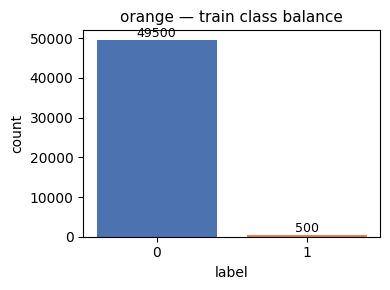

In [7]:
# Coarse task: food_containers (~5% positives)
y_food = np.isin(train_coarse, [COARSE_ID["food_containers"]]).astype(np.int64)
plot_task_samples(train_images, y_food, title="food_containers vs rest")
plot_class_balance(y_food, title="food_containers — train class balance")

# Fine task: skyscraper (~1% positives)
y_sky = np.isin(train_fine, [FINE_ID["skyscraper"]]).astype(np.int64)
plot_task_samples(train_images, y_sky, title="skyscraper vs rest")
plot_class_balance(y_sky, title="skyscraper — train class balance")

# Fine task: orange (~1% positives) — the augmentation ablation target
y_orange = np.isin(train_fine, [FINE_ID["orange"]]).astype(np.int64)
plot_task_samples(train_images, y_orange, title="orange vs rest")
plot_class_balance(y_orange, title="orange — train class balance")


## 3. Build the Binary Task

Reusable binary and multiclass task builders. The runner loop selects between them per experiment.

In [8]:
def make_binary_labels(labels: np.ndarray, positive_ids) -> np.ndarray:
    """Return int64 {0, 1} labels; members of positive_ids become 1."""
    positive_set = {int(i) for i in positive_ids}
    if not positive_set:
        return np.zeros_like(labels, dtype=np.int64)
    return np.isin(labels, list(positive_set)).astype(np.int64)


def label_maps():
    """Build label-name maps from the loaded CIFAR-100 metadata."""
    missing = [name for name in ("fine_names", "coarse_names") if name not in globals()]
    if missing:
        raise RuntimeError(
            "Run the CIFAR-100 loading cell before task-builder/runner cells; "
            f"missing: {', '.join(missing)}"
        )
    return (
        {name: i for i, name in enumerate(fine_names)},
        {name: i for i, name in enumerate(coarse_names)},
    )


def binary_task(label_level: str, positive_names: list[str]):
    """Return (y_train, y_test, task_description_str) for a binary task."""
    fine_id, coarse_id = label_maps()
    if label_level == "coarse":
        pos_ids = [coarse_id[n] for n in positive_names]
        y_tr = make_binary_labels(train_coarse, pos_ids)
        y_te = make_binary_labels(test_coarse,  pos_ids)
    else:
        pos_ids = [fine_id[n] for n in positive_names]
        y_tr = make_binary_labels(train_fine, pos_ids)
        y_te = make_binary_labels(test_fine,  pos_ids)
    desc = f"{label_level}/{'+'.join(positive_names)} vs rest"
    print(f"task: {desc}  train {dict(Counter(y_tr.tolist()))}  test {dict(Counter(y_te.tolist()))}")
    return y_tr, y_te, desc


def multiclass_task():
    """Return (y_train, y_test, description) for 20-way coarse classification."""
    desc = "coarse multiclass (20-way)"
    print(f"task: {desc}  train classes: {len(np.unique(train_coarse))}")
    return train_coarse.astype(np.int64), test_coarse.astype(np.int64), desc

## 4. Stratified Subset for the Smoke Run

Naive head slicing of CIFAR-100 can leave the rare positive class out of the smoke subset. We instead take a deterministic stratified subset (matching `training/train.py::_stratified_subset`).


In [9]:
def stratified_subset(images, labels, *, subset_size, seed):
    """Deterministic stratified subset over all labels present."""
    if subset_size is None or subset_size >= labels.shape[0]:
        return images, labels
    if subset_size < 2:
        raise ValueError("subset_size must be at least 2 when set")

    rng = np.random.default_rng(seed)
    selected_parts = []
    classes = np.unique(labels)
    for cls in classes:
        cls_idx = np.flatnonzero(labels == cls)
        n_cls = max(1, int(round(subset_size * cls_idx.size / labels.shape[0])))
        n_cls = min(n_cls, cls_idx.size)
        selected_parts.append(rng.choice(cls_idx, size=n_cls, replace=False))

    selected = np.concatenate(selected_parts)
    if selected.shape[0] > subset_size:
        selected = rng.choice(selected, size=subset_size, replace=False)
    elif selected.shape[0] < subset_size:
        remaining = np.setdiff1d(
            np.arange(labels.shape[0]),
            selected,
            assume_unique=False,
        )
        extra = rng.choice(
            remaining,
            size=min(subset_size - selected.shape[0], remaining.shape[0]),
            replace=False,
        )
        selected = np.concatenate([selected, extra])

    rng.shuffle(selected)
    return images[selected], labels[selected]

## 5. Stratified Train/Validation Split

Reimplements `training/splits.py::stratified_train_val_split`: shuffle per-class indices with a seeded RNG, peel off `val_fraction` per class, reshuffle the union so positives and negatives are interleaved.


In [10]:
def stratified_train_val_split(images, labels, *, val_fraction=0.1, seed=42):
    """Split into train/validation with per-class sampling."""
    rng = np.random.default_rng(seed)
    train_parts, val_parts = [], []
    for cls in np.unique(labels):
        idx = np.flatnonzero(labels == cls)
        rng.shuffle(idx)
        n_val = max(1, int(round(len(idx) * val_fraction)))
        n_val = min(n_val, max(len(idx) - 1, 1))
        val_parts.append(idx[:n_val])
        train_parts.append(idx[n_val:])

    train_idx = np.concatenate(train_parts)
    val_idx = np.concatenate(val_parts)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return images[train_idx], labels[train_idx], images[val_idx], labels[val_idx]

## 6. `tf.data` Pipelines

Mirrors `data.make_pipeline(view="image")`: cast to float32, normalize to `[0, 1]`, shuffle (train only) with a seeded buffer, batch, prefetch.


In [11]:
def make_pipeline(images, labels, *, batch_size, shuffle, shuffle_buffer=1024, seed=None):
    """Build a tf.data.Dataset that yields (float32 image in [0,1], int64 label)."""
    images_f32 = images.astype(np.float32, copy=False) / 255.0
    labels_i64 = labels.astype(np.int64, copy=False)
    ds = tf.data.Dataset.from_tensor_slices((images_f32, labels_i64))
    if shuffle:
        ds = ds.shuffle(
            buffer_size=shuffle_buffer,
            seed=seed,
            reshuffle_each_iteration=False,
        )
    ds = ds.batch(batch_size, drop_remainder=False)
    return ds.prefetch(tf.data.AUTOTUNE)

## 7. Baseline CNN Model

Inlined from `models/baseline.py`: two conv blocks (32, then 64 filters), max-pool + dropout after each, then a 128-unit dense head with sigmoid output. Returned uncompiled so we can compile it explicitly below.


In [12]:
def make_augmentation_layer() -> tf.keras.Sequential:
    """Light augmentation — horizontal flip, small translation, small zoom.

    Rotation is intentionally disabled: it is safe for round objects like
    orange but hurts classes like skyscraper, vehicles, and people.
    Attach only for the orange_aug_light experiment.
    """
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomTranslation(0.05, 0.05),
            tf.keras.layers.RandomZoom(0.05),
        ],
        name="augmentation",
    )

In [13]:
keras  = tf.keras
layers = tf.keras.layers


def build_baseline_cnn(
    input_shape=(32, 32, 3),
    dropout: float = 0.3,
    num_classes: int = 1,
    augmentation=None,
):
    """Two-block CNN. augmentation: optional Keras layer prepended before conv blocks."""
    inputs = keras.Input(shape=input_shape, name="image")
    x = augmentation(inputs) if augmentation is not None else inputs
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    if num_classes == 1:
        outputs = layers.Dense(1, activation="sigmoid", name="prob")(x)
    else:
        outputs = layers.Dense(num_classes, activation="softmax", name="prob")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="baseline_cnn")

### Baseline architecture sanity check

A one-shot `model.summary()` on the single controlled baseline CNN. Deeper
backbones (MobileNetV3, EfficientNet, ResNet) and a ViT are covered in
separate notebooks — this notebook keeps one fixed architecture so all
experiments are comparable.


In [14]:
demo_model = build_baseline_cnn(num_classes=1)
demo_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob (Dense)                    │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 590,113 (2.25 MB)

 Trainable params: 590,113 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Curated Experiment Runner

Evaluation helpers for binary and multiclass tasks, the six curated experiment configs, and
the runner loop. Each experiment appends a metrics dict to `all_results`.

In [15]:
def compute_balanced_class_weights(labels):
    """sklearn-balanced class weights for binary labels."""
    labels = np.asarray(labels).reshape(-1)
    classes = np.unique(labels)
    if classes.size < 2:
        return {0: 1.0, 1: 1.0}
    w = compute_class_weight(class_weight="balanced", classes=classes, y=labels)
    return {int(c): float(v) for c, v in zip(classes, w)}

In [16]:
def evaluate_binary(model, val_ds, test_ds, y_val, y_test):
    """Evaluate binary model. Selects best threshold on val F1.

    Returns (metrics, diagnostics). `metrics` keeps the same shape as before
    (threshold, precision, recall, f1, roc_auc, pr_auc, confusion_matrix).
    `diagnostics` carries y_true / y_prob / threshold for downstream plots —
    kept separate so callers can drop it for large/unused tasks.
    """
    # Best threshold on validation
    val_prob = model.predict(val_ds, verbose=0).reshape(-1)
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.91, 0.05):
        f = f1_score(y_val, (val_prob >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_thresh = f, t

    # Test evaluation at best threshold
    test_prob = model.predict(test_ds, verbose=0).reshape(-1)
    y_pred = (test_prob >= best_thresh).astype(np.int64)
    y_true = y_test.astype(np.int64)

    try:
        roc_auc = float(roc_auc_score(y_true, test_prob))
    except ValueError:
        roc_auc = float("nan")
    try:
        pr_auc = float(average_precision_score(y_true, test_prob))
    except ValueError:
        pr_auc = float("nan")

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()
    metrics = {
        "threshold": round(float(best_thresh), 2),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc":   roc_auc,
        "pr_auc":    pr_auc,
        "confusion_matrix": cm,
    }
    diagnostics = {
        "y_true":    y_true,
        "y_prob":    test_prob,
        "threshold": float(best_thresh),
    }
    return metrics, diagnostics


In [17]:
def top_k_accuracy(y_true, y_prob, k):
    """Fraction of samples where true label is in the top-k predicted classes."""
    top_k = np.argsort(y_prob, axis=1)[:, -k:]
    return float(np.mean([y_true[i] in top_k[i] for i in range(len(y_true))]))


def evaluate_multiclass(model, test_ds, y_test):
    """Evaluate multiclass model. Returns macro-F1, top-3, top-5 accuracy."""
    y_prob = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1).astype(np.int64)
    y_true = y_test.astype(np.int64)
    return {
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "macro_f1":     float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "top3_accuracy": top_k_accuracy(y_true, y_prob, 3),
        "top5_accuracy": top_k_accuracy(y_true, y_prob, 5),
    }

## 8b. Visual Diagnostics Helpers

Plotting helpers reused after the runner loop:

- `plot_history` — loss/accuracy curves per epoch.
- `plot_confusion_matrix` — 2x2 heatmap for binary tasks.
- `plot_binary_metric_bars` — F1 and PR-AUC bars across selected binary tasks.
- `plot_pr_curve` — precision-recall curves for `orange` vs `orange_aug_light`.
- `plot_prediction_grid` — image grid with true label, predicted label, and probability.

All helpers use Matplotlib only (no seaborn) to keep the notebook lightweight.


In [18]:
from sklearn.metrics import precision_recall_curve


def plot_history(history_dict, title=""):
    """Plot loss and accuracy curves over epochs."""
    epochs = range(1, len(history_dict.get("loss", [])) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    if "loss" in history_dict:
        axes[0].plot(epochs, history_dict["loss"], label="train")
    if "val_loss" in history_dict:
        axes[0].plot(epochs, history_dict["val_loss"], label="val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
    axes[0].set_title("loss")

    if "accuracy" in history_dict:
        axes[1].plot(epochs, history_dict["accuracy"], label="train")
    if "val_accuracy" in history_dict:
        axes[1].plot(epochs, history_dict["val_accuracy"], label="val")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
    axes[1].set_title("accuracy")

    if title:
        fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, title=""):
    """2x2 confusion matrix heatmap with cell-count annotations."""
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(3.2, 3.0))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred 0", "pred 1"])
    ax.set_yticklabels(["true 0", "true 1"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(int(cm[i, j])), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=10)
    if title:
        ax.set_title(title, fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_binary_metric_bars(results, task_names=None, metrics=("f1", "pr_auc")):
    """Grouped bar chart comparing binary tasks by selected metrics."""
    binary_results = [r for r in results if "f1" in r]
    if task_names is not None:
        wanted = set(task_names)
        binary_results = [r for r in binary_results if r["name"] in wanted]
        order = {n: i for i, n in enumerate(task_names)}
        binary_results.sort(key=lambda r: order.get(r["name"], 1e9))
    names = [r["name"] for r in binary_results]
    if not names:
        print("plot_binary_metric_bars: no matching binary results")
        return
    x = np.arange(len(names))
    width = 0.8 / len(metrics)
    fig, ax = plt.subplots(figsize=(max(5, 1.1 * len(names)), 3.2))
    for i, m in enumerate(metrics):
        vals = [r.get(m, float("nan")) for r in binary_results]
        ax.bar(x + i * width - 0.4 + width / 2, vals, width=width, label=m)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("score")
    ax.set_title("Binary task comparison")
    ax.legend()
    fig.tight_layout()
    plt.show()


def plot_pr_curve(diagnostics_by_name, task_names, title=""):
    """Overlay precision-recall curves for the given task names."""
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    plotted = 0
    for name in task_names:
        diag = diagnostics_by_name.get(name)
        if not diag:
            continue
        y_true = np.asarray(diag["y_true"]).reshape(-1)
        y_prob = np.asarray(diag["y_prob"]).reshape(-1)
        if y_true.size == 0:
            continue
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap = float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) == 2 else float("nan")
        ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
        plotted += 1
    if plotted == 0:
        print("plot_pr_curve: no diagnostics available for", task_names)
        plt.close(fig)
        return
    ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    if title:
        ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


def plot_prediction_grid(images, y_true, y_prob, threshold, *, title="", n=16):
    """Grid of test images annotated with true/pred labels and probability.

    Prioritizes false positives and false negatives, then fills with correct
    predictions so the grid is always exactly n cells when possible.
    """
    images = np.asarray(images)
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(np.int64)

    fp_idx = np.flatnonzero((y_pred == 1) & (y_true == 0))
    fn_idx = np.flatnonzero((y_pred == 0) & (y_true == 1))
    ok_idx = np.flatnonzero(y_pred == y_true)

    rng = np.random.default_rng(SEED)
    def take(arr, k):
        if arr.size == 0 or k <= 0:
            return np.array([], dtype=int)
        return rng.choice(arr, size=min(k, arr.size), replace=False)

    half = n // 2
    pick = np.concatenate([take(fp_idx, half // 2), take(fn_idx, half - half // 2)])
    if pick.size < n:
        pick = np.concatenate([pick, take(ok_idx, n - pick.size)])
    pick = pick[:n]

    cols = 4
    rows = int(np.ceil(len(pick) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.7, rows * 1.9))
    axes = np.atleast_2d(axes).reshape(-1)
    for ax, idx in zip(axes, pick):
        img = images[idx]
        if img.dtype != np.uint8:
            img = np.clip(img, 0.0, 1.0)
        ax.imshow(img)
        marker = "OK" if y_pred[idx] == y_true[idx] else "X"
        ax.set_title(
            f"{marker} t={int(y_true[idx])} p={int(y_pred[idx])}\nprob={y_prob[idx]:.2f}",
            fontsize=8,
        )
        ax.axis("off")
    for ax in axes[len(pick):]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


In [19]:
# Curated experiment definitions.
# Each dict is consumed by the runner loop below.
EXPERIMENTS = [
    {
        "name": "food_containers",
        "type": "binary",
        "label_level": "coarse",
        "positive_names": ["food_containers"],
        "dropout": 0.3,
        "lr": 1e-4,
    },
    {
        "name": "aquatic_mammals",
        "type": "binary",
        "label_level": "coarse",
        "positive_names": ["aquatic_mammals"],
        "dropout": 0.3,
        "lr": 3e-5,
    },
    {
        "name": "skyscraper",
        "type": "binary",
        "label_level": "fine",
        "positive_names": ["skyscraper"],
        "dropout": 0.3,
        "lr": 1e-5,
    },
    {
        "name": "orange",
        "type": "binary",
        "label_level": "fine",
        "positive_names": ["orange"],
        "dropout": 0.3,
        "lr": 1e-5,
    },
    {
        "name": "orange_aug_light",
        "type": "binary",
        "label_level": "fine",
        "positive_names": ["orange"],
        "dropout": 0.3,
        "lr": 1e-5,
        "augmentation": True,   # attach make_augmentation_layer()
    },
    {
        "name": "coarse_multiclass",
        "type": "multiclass",
        "dropout": 0.3,
        "lr": 3e-5,
    },
]

# To add another task, append a dict following the same schema above.
# Example (commented out):
# {"name": "cattle", "type": "binary", "label_level": "fine",
#  "positive_names": ["cattle"], "dropout": 0.3, "lr": 1e-4}

In [20]:
all_results = []
diagnostics_by_name = {}
DIAGNOSTICS_TASKS = {"skyscraper", "orange", "orange_aug_light"}

for exp in EXPERIMENTS:
    name = exp["name"]
    epochs = (FAST_EPOCHS if FAST_DEV_RUN else DEFAULT_EPOCHS)[name]
    subset = FAST_SUBSET if FAST_DEV_RUN else None
    lr = exp["lr"]
    dropout = exp["dropout"]
    is_multi = exp["type"] == "multiclass"

    print(f"\n{'='*60}")
    print(f"Experiment: {name}  |  epochs={epochs}  |  lr={lr}")
    print(f"{'='*60}")

    # --- Build task labels ---
    if is_multi:
        y_tr_full, y_te_full, desc = multiclass_task()
        num_classes = len(np.unique(y_tr_full))
    else:
        y_tr_full, y_te_full, desc = binary_task(
            exp["label_level"], exp["positive_names"]
        )
        num_classes = 1

    # --- Subset (FAST_DEV_RUN) ---
    img_tr, y_tr_s = stratified_subset(
        train_images, y_tr_full, subset_size=subset, seed=SEED
    )
    img_te, y_te_s = stratified_subset(
        test_images, y_te_full, subset_size=subset, seed=SEED + 1
    )

    # --- Train/val split ---
    x_tr, y_tr, x_val, y_val = stratified_train_val_split(
        img_tr, y_tr_s, val_fraction=0.1, seed=SEED
    )

    # --- Pipelines ---
    train_ds = make_pipeline(x_tr, y_tr, batch_size=64, shuffle=True, seed=SEED)
    val_ds   = make_pipeline(x_val, y_val, batch_size=64, shuffle=False)
    test_ds  = make_pipeline(img_te, y_te_s, batch_size=64, shuffle=False)

    # --- Class weights (binary only) ---
    if num_classes == 1:
        cw = compute_balanced_class_weights(y_tr)
    else:
        cw = None

    # --- Model ---
    aug_layer = make_augmentation_layer() if exp.get("augmentation") else None
    tf.keras.backend.clear_session()
    model = build_baseline_cnn(dropout=dropout, num_classes=num_classes,
                               augmentation=aug_layer)

    loss = (tf.keras.losses.BinaryCrossentropy(from_logits=False)
            if num_classes == 1
            else tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=["accuracy"],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ]
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs, class_weight=cw, callbacks=callbacks, verbose=2,
    )

    # --- Evaluate ---
    if num_classes == 1:
        metrics, diagnostics = evaluate_binary(model, val_ds, test_ds, y_val, y_te_s)
        if name in DIAGNOSTICS_TASKS:
            diagnostics_by_name[name] = diagnostics
    else:
        metrics = evaluate_multiclass(model, test_ds, y_te_s)

    metrics["name"] = name
    metrics["desc"] = desc
    metrics["history"] = history.history
    all_results.append(metrics)
    log_metrics = {k: v for k, v in metrics.items() if k != "history"}
    print(f"  result: {log_metrics}")



Experiment: food_containers  |  epochs=20  |  lr=0.0001
task: coarse/food_containers vs rest  train {0: 47500, 1: 2500}  test {0: 9500, 1: 500}
Epoch 1/20
704/704 - 21s - 30ms/step - accuracy: 0.6038 - loss: 0.6482 - val_accuracy: 0.7112 - val_loss: 0.5930
Epoch 2/20
704/704 - 4s - 6ms/step - accuracy: 0.7246 - loss: 0.5596 - val_accuracy: 0.7594 - val_loss: 0.5150
Epoch 3/20
704/704 - 4s - 6ms/step - accuracy: 0.7461 - loss: 0.5115 - val_accuracy: 0.7750 - val_loss: 0.4719
Epoch 4/20
704/704 - 5s - 7ms/step - accuracy: 0.7584 - loss: 0.4874 - val_accuracy: 0.8378 - val_loss: 0.3832
Epoch 5/20
704/704 - 5s - 6ms/step - accuracy: 0.7706 - loss: 0.4696 - val_accuracy: 0.8322 - val_loss: 0.3921
Epoch 6/20
704/704 - 5s - 7ms/step - accuracy: 0.7836 - loss: 0.4539 - val_accuracy: 0.8336 - val_loss: 0.3847
Epoch 7/20
704/704 - 5s - 7ms/step - accuracy: 0.7967 - loss: 0.4323 - val_accuracy: 0.8320 - val_loss: 0.3778
Epoch 8/20
704/704 - 5s - 7ms/step - accuracy: 0.8036 - loss: 0.4205 - val_a

In [21]:
print("\n" + "=" * 90)
print("RESULT TABLE")
print("=" * 90)

# Binary rows
print(f"\n{'Task':<22} {'thresh':>6} {'P':>6} {'R':>6} {'F1':>6} {'ROC-AUC':>8} {'PR-AUC':>7}")
print("-" * 65)
for r in all_results:
    if "f1" in r:
        print(
            f"{r['name']:<22} {r['threshold']:>6.2f} "
            f"{r['precision']:>6.3f} {r['recall']:>6.3f} {r['f1']:>6.3f} "
            f"{r['roc_auc']:>8.3f} {r['pr_auc']:>7.3f}"
        )

# Multiclass rows
print(f"\n{'Task':<22} {'acc':>6} {'macro-F1':>9} {'top-3':>6} {'top-5':>6}")
print("-" * 55)
for r in all_results:
    if "macro_f1" in r:
        print(
            f"{r['name']:<22} {r['accuracy']:>6.3f} "
            f"{r['macro_f1']:>9.3f} {r['top3_accuracy']:>6.3f} {r['top5_accuracy']:>6.3f}"
        )
print("=" * 90)


RESULT TABLE

Task                   thresh      P      R     F1  ROC-AUC  PR-AUC
-----------------------------------------------------------------
food_containers          0.85  0.589  0.580  0.585    0.927   0.568
aquatic_mammals          0.85  0.408  0.406  0.407    0.890   0.386
skyscraper               0.90  0.183  0.570  0.277    0.958   0.237
orange                   0.90  0.286  0.810  0.423    0.984   0.417
orange_aug_light         0.90  0.241  0.780  0.369    0.979   0.354

Task                      acc  macro-F1  top-3  top-5
-------------------------------------------------------
coarse_multiclass       0.410     0.404  0.670  0.787


## 9. Visual Diagnostics

The runner stored `history.history` for every experiment and `(y_true, y_prob,
threshold)` for the three selected binary tasks `skyscraper`, `orange`, and
`orange_aug_light`. The cells below turn that into visualizations: a metric
comparison bar chart, training curves for the selected runs, confusion matrices,
a precision-recall overlay for the augmentation ablation, and a prediction-grid
spot-check.


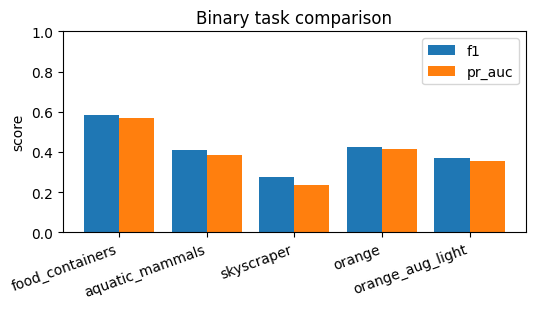

In [22]:
selected_binary = [
    "food_containers",
    "aquatic_mammals",
    "skyscraper",
    "orange",
    "orange_aug_light",
]
plot_binary_metric_bars(all_results, task_names=selected_binary, metrics=("f1", "pr_auc"))


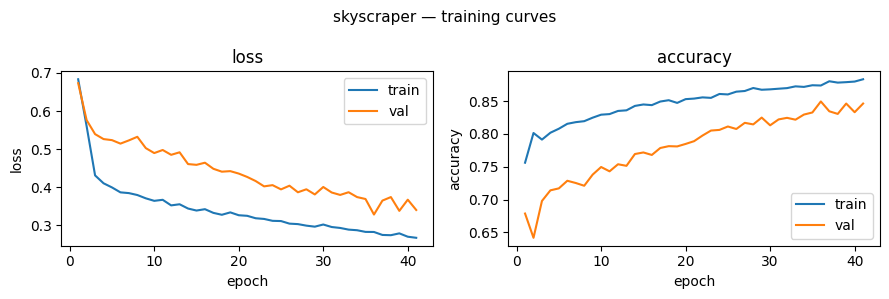

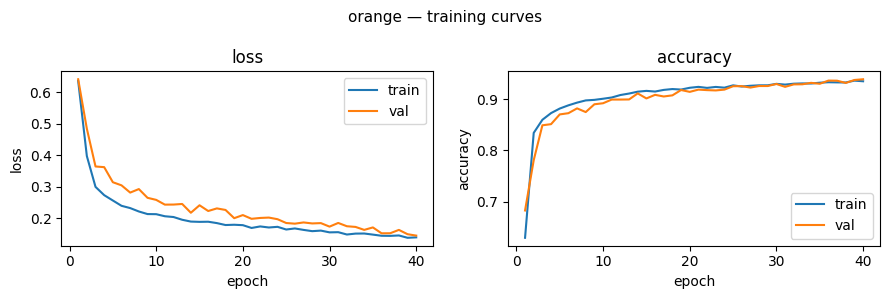

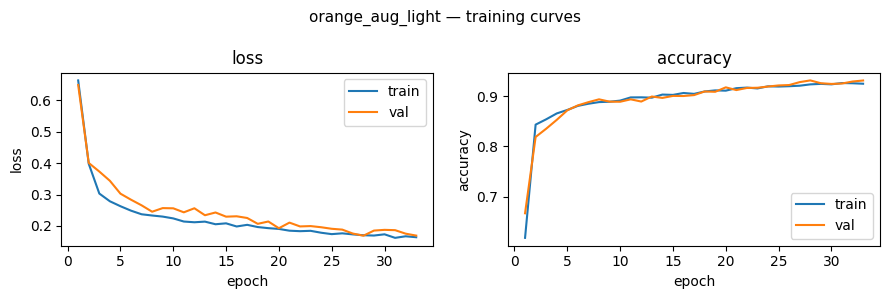

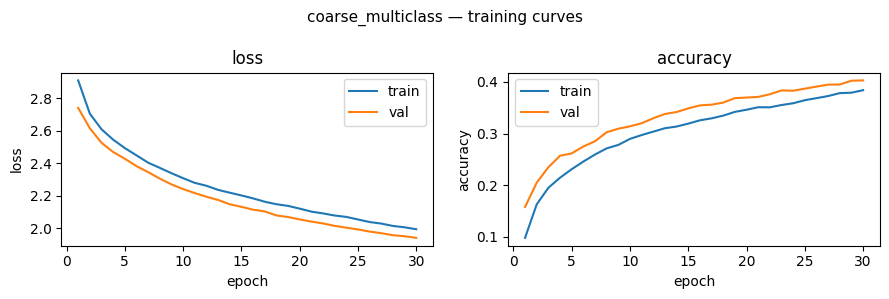

In [23]:
results_by_name = {r["name"]: r for r in all_results}
for name in ["skyscraper", "orange", "orange_aug_light", "coarse_multiclass"]:
    r = results_by_name.get(name)
    if r is None or "history" not in r:
        print(f"skip training curves for {name} — no history stored")
        continue
    plot_history(r["history"], title=f"{name} — training curves")


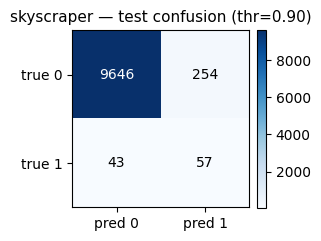

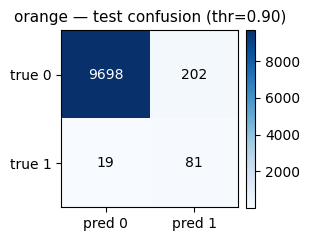

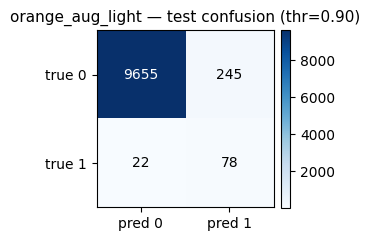

In [24]:
for name in ["skyscraper", "orange", "orange_aug_light"]:
    r = results_by_name.get(name)
    if r is None or "confusion_matrix" not in r:
        print(f"skip confusion matrix for {name} — no result")
        continue
    plot_confusion_matrix(r["confusion_matrix"], title=f"{name} — test confusion (thr={r['threshold']:.2f})")


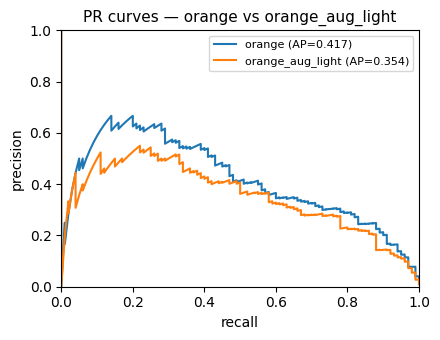

In [25]:
plot_pr_curve(
    diagnostics_by_name,
    task_names=["orange", "orange_aug_light"],
    title="PR curves — orange vs orange_aug_light",
)


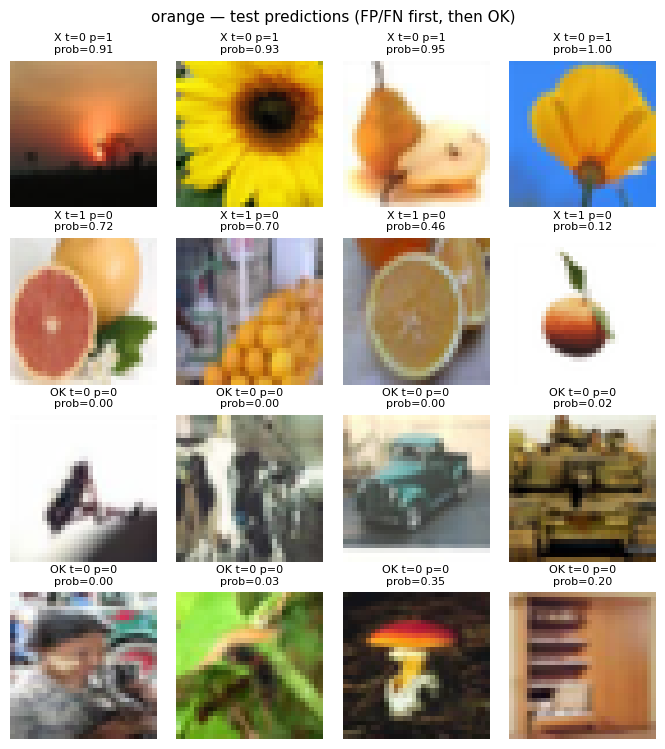

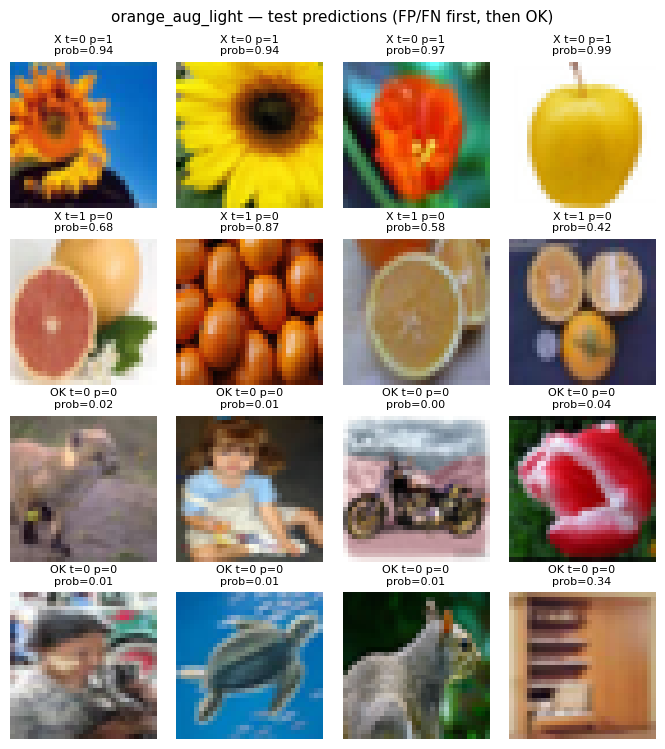

In [26]:
# Spot-check predictions for the orange ablation pair.
# Recompute the deterministic test subset locally so we don't have to store
# image arrays in all_results / diagnostics_by_name.
subset_size = FAST_SUBSET if FAST_DEV_RUN else None
y_orange_full = np.isin(test_fine, [FINE_ID["orange"]]).astype(np.int64)
img_te_orange, _ = stratified_subset(
    test_images, y_orange_full, subset_size=subset_size, seed=SEED + 1
)

for name in ["orange", "orange_aug_light"]:
    diag = diagnostics_by_name.get(name)
    if not diag:
        print(f"skip prediction grid for {name} — no diagnostics")
        continue
    plot_prediction_grid(
        img_te_orange,
        diag["y_true"],
        diag["y_prob"],
        diag["threshold"],
        title=f"{name} — test predictions (FP/FN first, then OK)",
        n=16,
    )


## Interpretation

**Binary tasks:** `skyscraper` typically achieves the highest F1/PR-AUC among fine tasks
at `lr=1e-5` with long training; `food_containers` is the strongest coarse baseline.
The metric comparison bars above visualize this directly. `orange_aug_light` trades
precision for recall vs. plain `orange` — the confusion matrices and PR-curve overlay
show augmentation reducing false negatives but adding false positives, which is why
it is framed as an augmentation **ablation** rather than the selected best orange model.
`aquatic_mammals` is the harder coarse task; the best run is around `lr=3e-5`,
`dropout=0.3`, 30 epochs.

**Training behavior:** the curves for `skyscraper` and the two `orange*` runs show
the long, gradual fit characteristic of the 1%-positive fine tasks under class
weighting. The `coarse_multiclass` curves show a smoother but lower ceiling fit.

**Multiclass:** The 20-way coarse baseline is intentionally modest. High top-5 accuracy
at modest macro-F1 shows the model ranks the true class plausibly but not distinctly —
motivating stronger architectures.


## Next Steps

The baseline CNN establishes lower-bound results per task. Planned improvements:

1. **Stronger CNN with BatchNorm + L2 regularization** — replace Dropout-only
   regularization with BatchNorm between conv layers and L2 weight decay.
2. **Transfer learning** — frozen EfficientNet/MobileNetV3/ResNet backbones for
   feature extraction, then partial fine-tuning. Expected large gain on fine tasks.
3. **Row-as-timestep sequential models** — RNN, LSTM, BiLSTM consuming each image
   as a T=32 sequence of 96-feature rows.
4. **Small ViT** — from-scratch patch-embedding attention model for architectural
   comparison on the same binary tasks.